\renewcommand{\maketitle}{}

\begin{titlepage}

\begin{center}

\vspace*{2cm}

{\Large Universidade de Brasília}\\[0.3cm]
{\large Departamento de Engenharia Elétrica}\\[2cm]

{\Large \textbf{
Comunicações Móveis - PPGEE
}}\\[1.5cm]

{\Huge \textbf{Trabalho 1}}\\[2cm]

{\large
Professor: Higo Thaian Pereira da Silva\\[0.3cm]
Aluno: Artur Padovesi Piratelli\\[0.3cm]
Matrícula: 261101032
}

\vfill

{\large Brasília}\\
{\large 2026}

\end{center}

\end{titlepage}

# Introdução

O documento 3GPP TR 38.901 pretende estender documentos anteriores, como o 38.900 e TU-R M.2135. Fornece modelagem de canal em cenários de deploy de redes celular, apropriado para a faixa de 0.5-100 GHz. Pode ser utilizado para simulações em nível de enlace ou de sistema.

Esse projeto se propõe a realizar uma modelagem semelhante à do documento original. Será implementada uma versão dos modelos de canal UMi, UMa e Indoor Open Office, com foco em nível de enlace.

O objetivo deste projeto é simular os canais UMi, UMa e Indoor Open Office simplificados, observando a dispersão de potência nos domínios de atraso, angular, o espectro doppler, as funções de autocorrelação e, por fim, o sinal recebido.

<!-- O objetivo, ao final, é analisar a dispersão de potência nos domínios de atraso, angular, o espectro doppler, as funções de autocorrelação e, por fim, o sinal recebido ao ser transmitido através desse canal. -->

# Implementação

A definição detalhada dos procedimentos podem ser encontradas no documento de referência [1].
Alguns procedimentos não possuem previsão no documento original. Os ângulos de zênite, caso em $[0°,360°)$, pode ser mapeado para a faixa correta caso os valores $[180, 360)$ sejam reavaliados por $\theta$ como $360 - \theta$. Para cálculo de dispersão de potência nas componentes multipercurso é especificado como lidar com a componente LoS (Line of Sight), mas não como lidar com o caso NLoS (No Line of Sight). Para o caso não previsto foi feita uma normalização simples considerando $\Omega_c = \sum_i \alpha_i^2$ e normalizando $\alpha_i$ com $\alpha_i / \Omega_c$. A maneira de lidar com as componentes de visada direta para definição dos ângulos de chegada não considera que a dispersão dos ângulos ocorre em volta da componente de visada direta, sugerindo apenas $\theta_0 = \theta_\text{LoS}$. Ao invés disso, foi feito o mapeamento $\theta_n = \theta_n - \theta_0 + \theta_\text{LoS}$ para todas as n-ésimas componentes, mantendo $\theta_0 = \theta_\text{LoS}$ enquanto leva a média da dispersão angular para essa componente.

Para qualquer enlace simulado são consideradas frequência central $f_c = 3$ GHz e $N = 100$ componentes multipercurso, cada uma com:

- Doppler;
- atraso;
- potência.

A caracterização do canal para obtenção da resposta ao impulso considera os seguintes parâmetros:

- espalhamento de atraso;
- fator de Rice;
- espalhamento Doppler, determinado pela velocidade do UT, ângulos de chegada e frequência da portadora;

## Cenários

Os cenários implementados, de interesse para redes celulares 5G, são:

- UMi (Canyon Urbano) com O2O (Outside to Outside), onde BSs são posicionadas abaixo do nível dos prédios;
- UMa com O2O, onde BSs são posicionadas acima do nível dos prédios;
- Indoor Open Office (InH Office): Busca representar ambientes de trabalho, compostos por áreas abertas de cubículos, escritórios com paredes, corredores, etc.

É importante notar que a modelagem original foi feita considerando cenários de implantação de IMT (International Mobile Telecommunications), como:

- geometria BS (Base Station) e UT (User Terminal);
- implantações setorizadas;
- suposições de UT, como mobilidade (velocidade) e altura.

Nesse contexto, valores típicos podem ser utilizados para definição dos parâmetros a serem utilizados em cada cenário, considerando os documentos [2] [3]:

| Cenário     | Altura da BS | Distância entre BS e UT | Altura da UT | Velocidade da UT |
| ----------- | ---- | ---- | ---- | ---- |
| UMi         | 10 m | 10 - 200 m | 1.5 m | 3 km/h |
| UMa         | 25 m | 35 - 800 m | 1.5 m | 3 km/h |
| InH Office  | 3 m | 0 - 150 m | 1.5 m | 3 km/h  |

In [1]:
from tgpp.link import Link
from tgpp.station import Station
from tgpp.channel import TGPPChannel, TGPPChannelModelEnum
from tgpp.signal import BaseBandSignal
from tgpp.geometry import Vec3
from tgpp.utils import (
    plot_received_signal, plot_angular_spectrum, plot_arrival_vectors,
    plot_doppler_spectrum, plot_frequency_autocorrelation, plot_pdp,
    plot_received_signal, plot_time_autocorrelation, ChannelAutocorrelation,
    compute_delay_spread
)

import numpy as np

N_TIME_SAMPLES = int(1e5)
N_PATHS = 100
UT_VELOCITY = 0.8  # m/s, from 3 km/h
UT_HEIGHT = 1.5  # m
FREQUENCY_GHZ = 3.0 # GHz

TGPP_CHANNEL_MODEL_ENUM_TO_READABLE = {
    TGPPChannelModelEnum.UMa: "UMa",
    TGPPChannelModelEnum.UMi: "UMi",
    TGPPChannelModelEnum.IndoorOpenOffice: "InH-Office",
}

In [2]:
umi_link = Link(
    tx=Station(
        pos=Vec3(0., 0., 10.),
        # mock signal, correct frequency
        signal=BaseBandSignal(FREQUENCY_GHZ, np.zeros(N_TIME_SAMPLES), np.linspace(0, 1e-3, N_TIME_SAMPLES))
    ),
    rx=Station(
        pos=Vec3(100., 0., UT_HEIGHT),
        speed_direction=Vec3(1, 0, 0), # same axis as LoS path
        velocity=UT_VELOCITY
    ),
    chn=TGPPChannel(N_PATHS, TGPPChannelModelEnum.UMi),
)
uma_link = Link(
    tx=Station(
        pos=Vec3(0., 0., 25.),
        # mock signal, correct frequency
        signal=BaseBandSignal(FREQUENCY_GHZ, np.zeros(N_TIME_SAMPLES), np.linspace(0, 1e-3, N_TIME_SAMPLES))
    ),
    rx=Station(
        pos=Vec3(0., 300., UT_HEIGHT),
        speed_direction=Vec3(0, 1, 0), # same axis as LoS path
        velocity=UT_VELOCITY
    ),
    chn=TGPPChannel(N_PATHS, TGPPChannelModelEnum.UMa),
)
inh_open_office_link = Link(
    tx=Station(
        pos=Vec3(0., 0., 3.),
        # mock signal, correct frequency
        signal=BaseBandSignal(FREQUENCY_GHZ, np.zeros(N_TIME_SAMPLES), np.linspace(0, 1e-3, N_TIME_SAMPLES))
    ),
    rx=Station(
        pos=Vec3(50., 50., UT_HEIGHT),
        speed_direction=Vec3(1, 1, 0), # same axis as LoS path, direction is automatically normalized in Station
        velocity=UT_VELOCITY
    ),
    chn=TGPPChannel(N_PATHS, TGPPChannelModelEnum.IndoorOpenOffice),
)
UMI_SEED = 13
UMA_SEED = 230
INH_OPEN_OFFICE_SEED = 12
umi_link.evaluate_channel(np.random.default_rng(UMI_SEED))
uma_link.evaluate_channel(np.random.default_rng(UMA_SEED))
inh_open_office_link.evaluate_channel(np.random.default_rng(INH_OPEN_OFFICE_SEED))
ALL_LINKS = [umi_link, uma_link, inh_open_office_link]

# Resultados

In [3]:
for link in ALL_LINKS:
    channel = link.chn
    print(f"Channel model: {TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[channel.channel_model]}")
    print(f"\tLoS component: {'Yes' if channel.los else 'No'}")

Channel model: UMi
	LoS component: No
Channel model: UMa
	LoS component: Yes
Channel model: InH-Office
	LoS component: Yes


## Perfil de Atraso de Potência

O perfil de atraso de potência demonstra o comportamento de filtragem do canal, semelhante a uma resposta ao impulso do canal. Ele permite visualizar como um impulso de potência unitária é "espalhado" no domínio do atraso.

Sendo assim, todas as componentes são normalizadas para que a potência espalhada seja unitária $\Omega_c = \sum_i \alpha_i^2 = 1$. Essas potências por componente possuem perfil médio exponencial decrescente de acordo com o atraso. Um sombreamento é aplicado sobre cada cluster. Caso exista LoS, a normalização aplicada faz com que a relação entre a primeira componente e as outras siga o fator de Rice.

A geração do espalhamento de atraso em simulação ocorre antes da normalização das potências, portanto seu valor efetivo pode discordar do valor inicialmente gerado.
O seu valor pode ser calculado a partir da equação:

\begin{equation*}
    \sigma_\tau = \sqrt{\dfrac{1}{\Omega_c} \sum_{n=1}^N \alpha_n^2 \cdot(\tau_n - \overline{\tau})^2} \, ,
\end{equation*}
onde $\Omega_c$ é o ganho do canal e $\overline{\tau}$ é o atraso médio, determinado por
\begin{equation*}
    \overline{\tau} = \dfrac{1}{\Omega_c} \sum_{n=1}^N\tau_n \alpha_n^2 \, .
\end{equation*}


In [4]:
for l in ALL_LINKS:
    print(TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[l.chn.channel_model])
    print("\tEspalhamento de atraso inicialmente gerado:", l.chn.sigma_tau)
    actual_ds = compute_delay_spread(l.chn.tau, l.chn.cluster_power)
    print("\tEspalhamento de atraso efetivo:", actual_ds)
    print("\tDiferença entre valor gerado e efetivo:",
        abs(l.chn.sigma_tau-actual_ds),
        f"({abs(l.chn.sigma_tau-actual_ds)/l.chn.sigma_tau*100:.2f}%)"
    )

UMi
	Espalhamento de atraso inicialmente gerado: 2.8847431085854706e-08
	Espalhamento de atraso efetivo: 2.7706908714545137e-08
	Diferença entre valor gerado e efetivo: 1.140522371309568e-09 (3.95%)
UMa
	Espalhamento de atraso inicialmente gerado: 6.933298609513405e-08
	Espalhamento de atraso efetivo: 4.585792579806331e-08
	Diferença entre valor gerado e efetivo: 2.3475060297070736e-08 (33.86%)
InH-Office
	Espalhamento de atraso inicialmente gerado: 2.729604927517706e-08
	Espalhamento de atraso efetivo: 2.0395276230630588e-08
	Diferença entre valor gerado e efetivo: 6.900773044546472e-09 (25.28%)


É possível notar que o valor de espalhamento de atraso gerado em simulação para o caso UMi, que possui NLoS, é bem semelhante ao calculado posteriormente. Enquanto isso, os casos que possuem LoS possuem um espalhamento de atraso efetivo consideravelmente menor quando comparado com o valor gerado na simulação. Considerando a normalização feita para os cenários LoS, a concentração de potência na primeira componente de fato distorce o valor previamente gerado, levando a um valor efetivo bem menor.

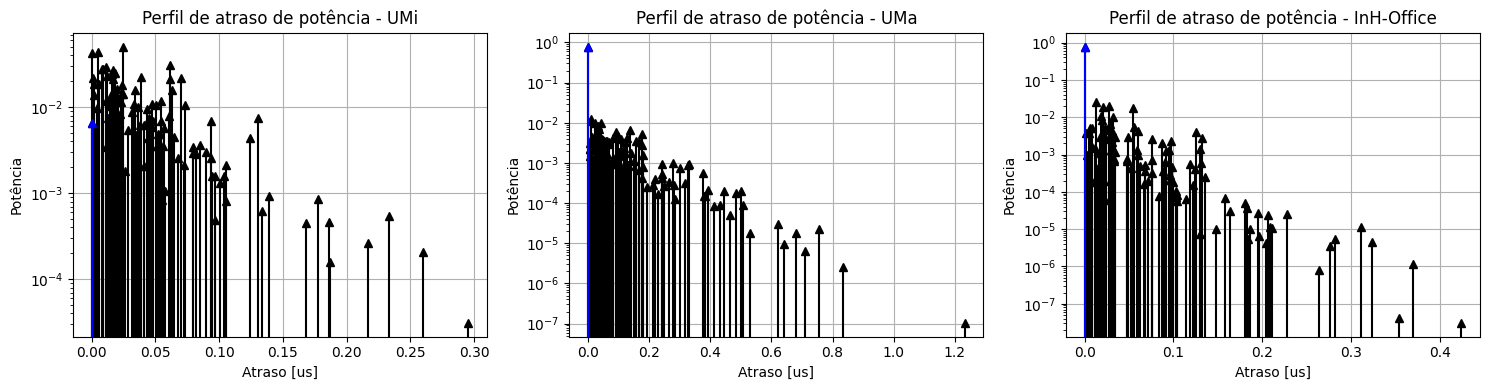

In [5]:
import math
import matplotlib.pyplot as plt

ncols = 3
n = len(ALL_LINKS)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
    squeeze=False,
)

axes = axes.flatten()

for ax, l in zip(axes, ALL_LINKS):
    plot_pdp(
        l.chn.tau,
        l.chn.cluster_power,
        ax=ax,
        scenario=TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[
            l.chn.channel_model
        ]
    )

# Hide unused axes
for ax in axes[n:]:
    ax.axis("off")

fig.tight_layout()

Pode-se observar que, para os casos UMa e InH-Office, onde houve presença de componente LoS, o primeiro atraso concentra a maior parte da potência. 
No caso UMi, onde ocorreu NLoS, o comportamento não se mantém, como esperado.

Além disso, UMa concentra maior potência na componente LoS do que InH-Office, indicando que houve um fator de Rice maior nessa realização de UMa do que na de InH-Office. Sendo assim, a realização com maior fator de Rice é o que apresentou maior diferença relativa entre os valores de espalhamento de atraso gerado e efetivo. Esse é mais um indicativo de que o valor efetivo de espalhamento de atraso é distorcido de acordo com o fator de Rice, possuindo espalhamento menor quanto mais o fator de Rice for maior.

## Perfis de Dispersão Angular

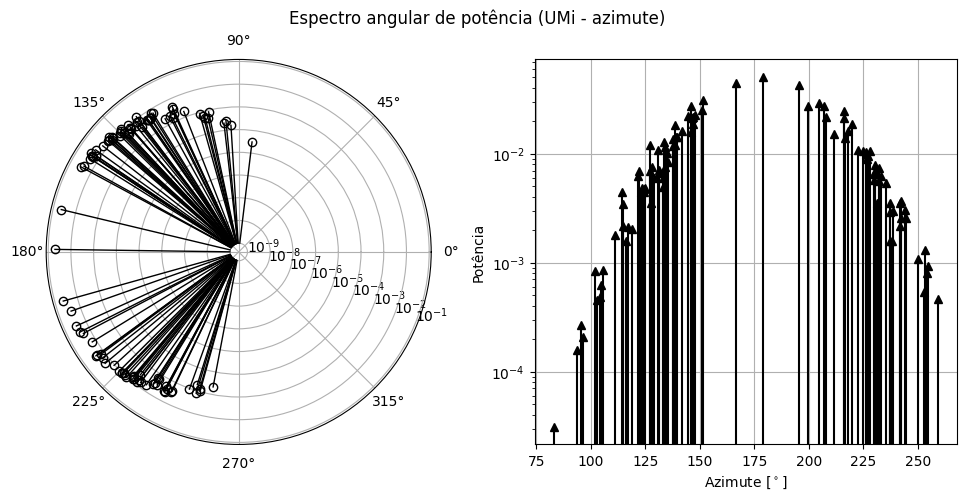

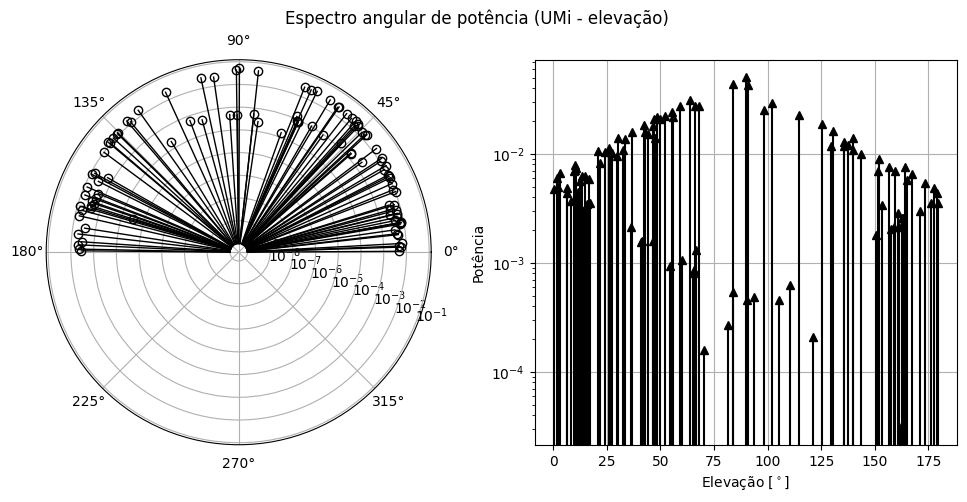

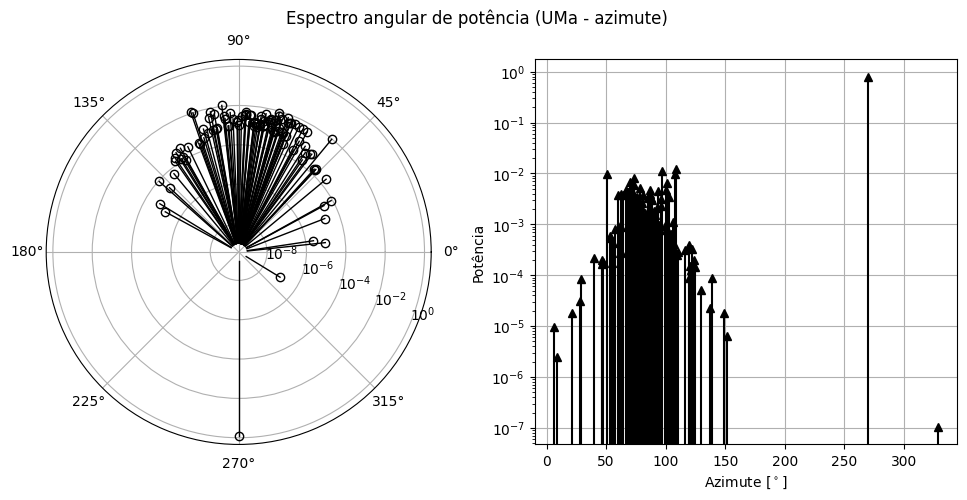

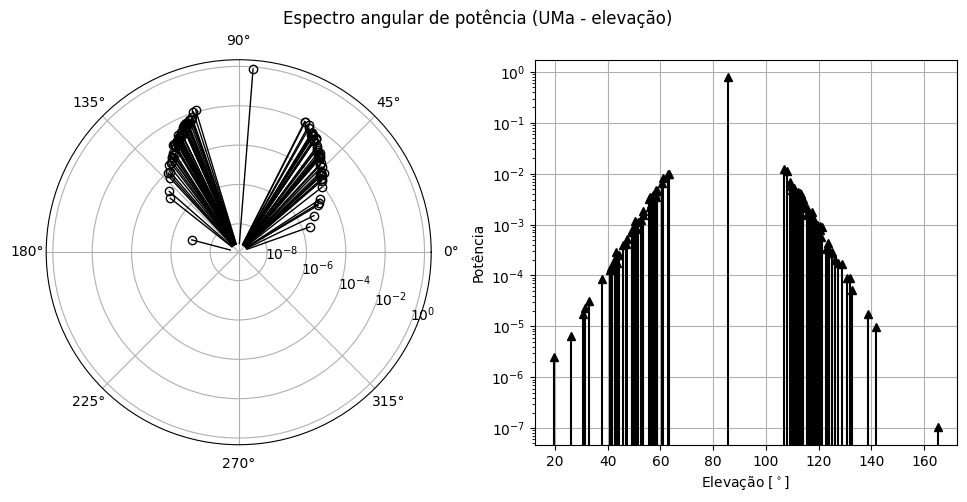

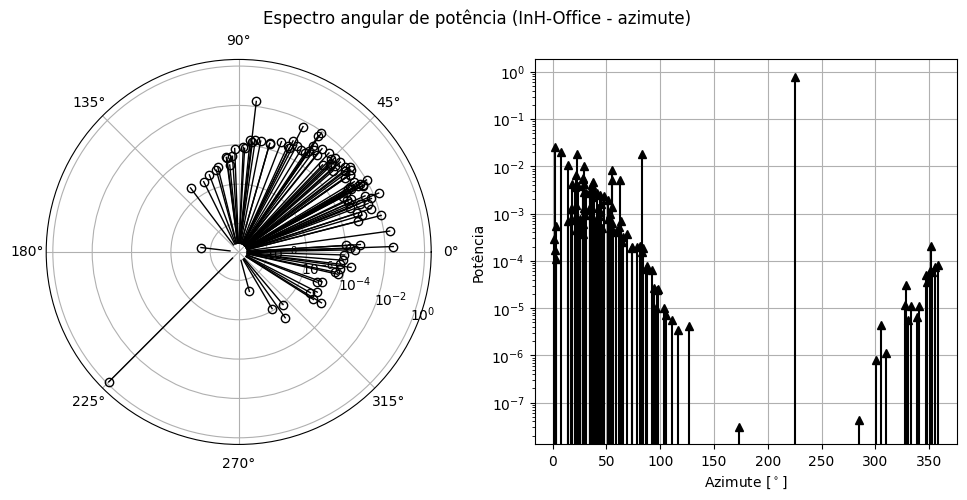

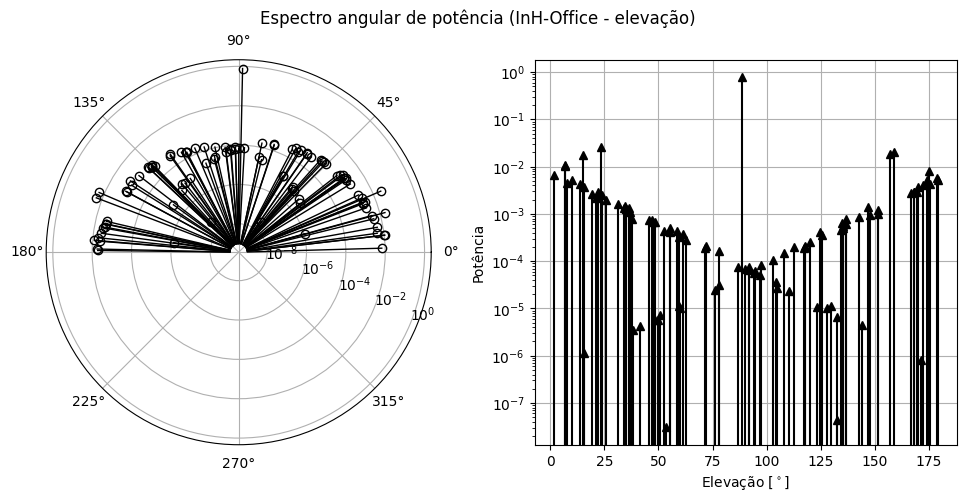

In [6]:
for l in ALL_LINKS:
    plot_angular_spectrum(
        l.chn.doa_azim,
        l.chn.cluster_power,
        angle_name="Azimute",
        scenario=TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[l.chn.channel_model]
    )

    plot_angular_spectrum(
        l.chn.doa_elev,
        l.chn.cluster_power,
        angle_name="Elevação",
        scenario=TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[l.chn.channel_model]
    )



Para UMi, que obteve realização com NLoS, é possível notar que a potência é dispersa nos domínios angulares de forma menos concentrada do que para os casos UMa e Indoor, que possuem LoS. Além disso, os ângulos de elevação se encontram corretamente entre 0 e 180°.

## Espectro Doppler

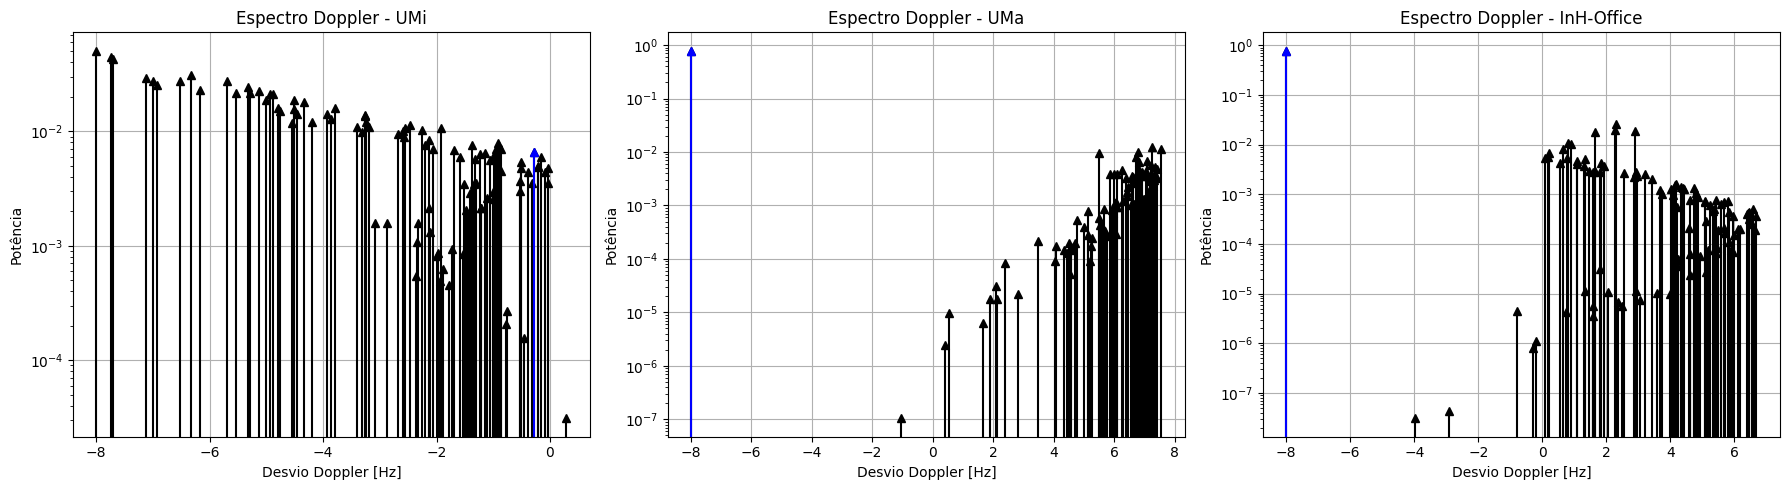

In [7]:
fig = plt.figure(figsize=(18, 5))

for col, l in enumerate(ALL_LINKS):

    chn = l.chn

    ax = fig.add_subplot(
        1, 3,
        col + 1,
    )

    plot_doppler_spectrum(
        chn.doppler,
        chn.cluster_power,
        ax=ax,
        scenario=TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[
            chn.channel_model
        ]
    )

fig.tight_layout()

Na configuração do cenário, a velocidade $v_{rx}$ do UT apontam no sentido oposto da direção para a BS. Sendo assim, para as realizações com LoS, UMa e InH-Office, a componente com ângulo de visada direta possui o maior desvio Doppler observável, e também sinal negativo.

O valor de Doppler para a n-ésima componente é dado por $\nu_n = \frac{1}{\lambda} r_n \cdot v_{rx}$, sendo $r_n$ o vetor direção de chegada. Considerando que a magnitude da velocidade é 0.8 m/s e frequência de transmissão é 3 GHz, então o valor máximo da magnitude do desvio Doppler é dado por $\frac{1}{0.1} 0.8 = 8$ Hz, em concordância com o observado.

## Funções de Autocorrelação

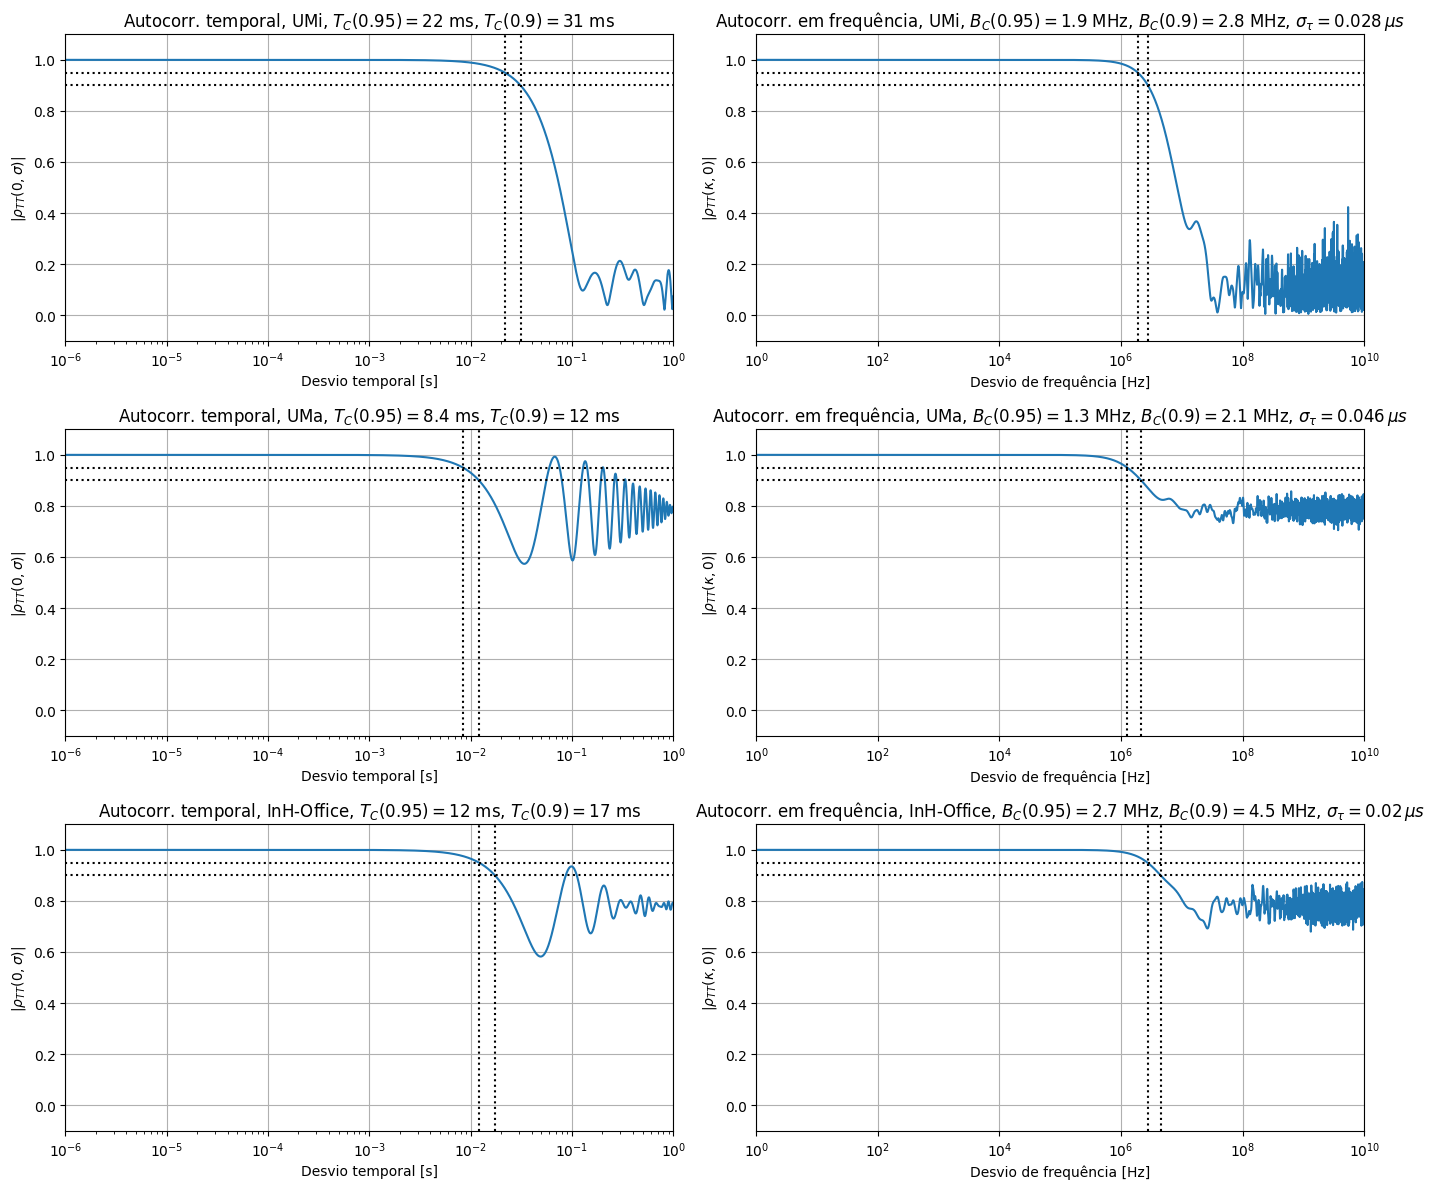

In [8]:
fig = plt.figure(figsize=(14, 12))

for row, l in enumerate(ALL_LINKS):
    channel = l.chn

    ac = ChannelAutocorrelation(
        channel.cluster_power,
        channel.tau,
        channel.doppler,
    )

    scenario = TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[
        channel.channel_model
    ]

    # =====================================================
    # Time autocorrelation
    # =====================================================

    ax_time = fig.add_subplot(
        3, 2,
        row * 2 + 1,
    )

    plot_time_autocorrelation(
        ac,
        ax=ax_time,
        # velocity=l.rx.velocity,
        # max_doppler=np.max(channel.doppler),
        scenario=scenario,
    )

    # =====================================================
    # Frequency autocorrelation
    # =====================================================

    ax_freq = fig.add_subplot(
        3, 2,
        row * 2 + 2,
    )

    actual_ds = compute_delay_spread(
        channel.tau,
        channel.cluster_power,
    )

    plot_frequency_autocorrelation(
        ac,
        ax=ax_freq,
        rms_delay_spread=actual_ds,
        scenario=scenario,
    )

fig.tight_layout()

Considerando um limiar de 0.9 para correlação, podem ser recolhidas os valores que mantém o sinal em coerência:

| Cenário | Banda de Coerência | Tempo de Coerência |
| ------- | ------------------ | ----- |
| UMi | 2.8 MHz | 31 ms |
| UMa | 2.1 MHz | 12 ms |
| Indoor Open Office | 4.5 MHz | 17 ms |

## Transmissão e Recepção

Deseja-se observar o fenômeno de seletividade em frequência do canal. Para isso, serão transmitidos três sinais retangulares por cenário, escolhendo os períodos $T_{\text{sig}} \in \{ 1/3 B_C, 1/B_C, 3/B_C \}$

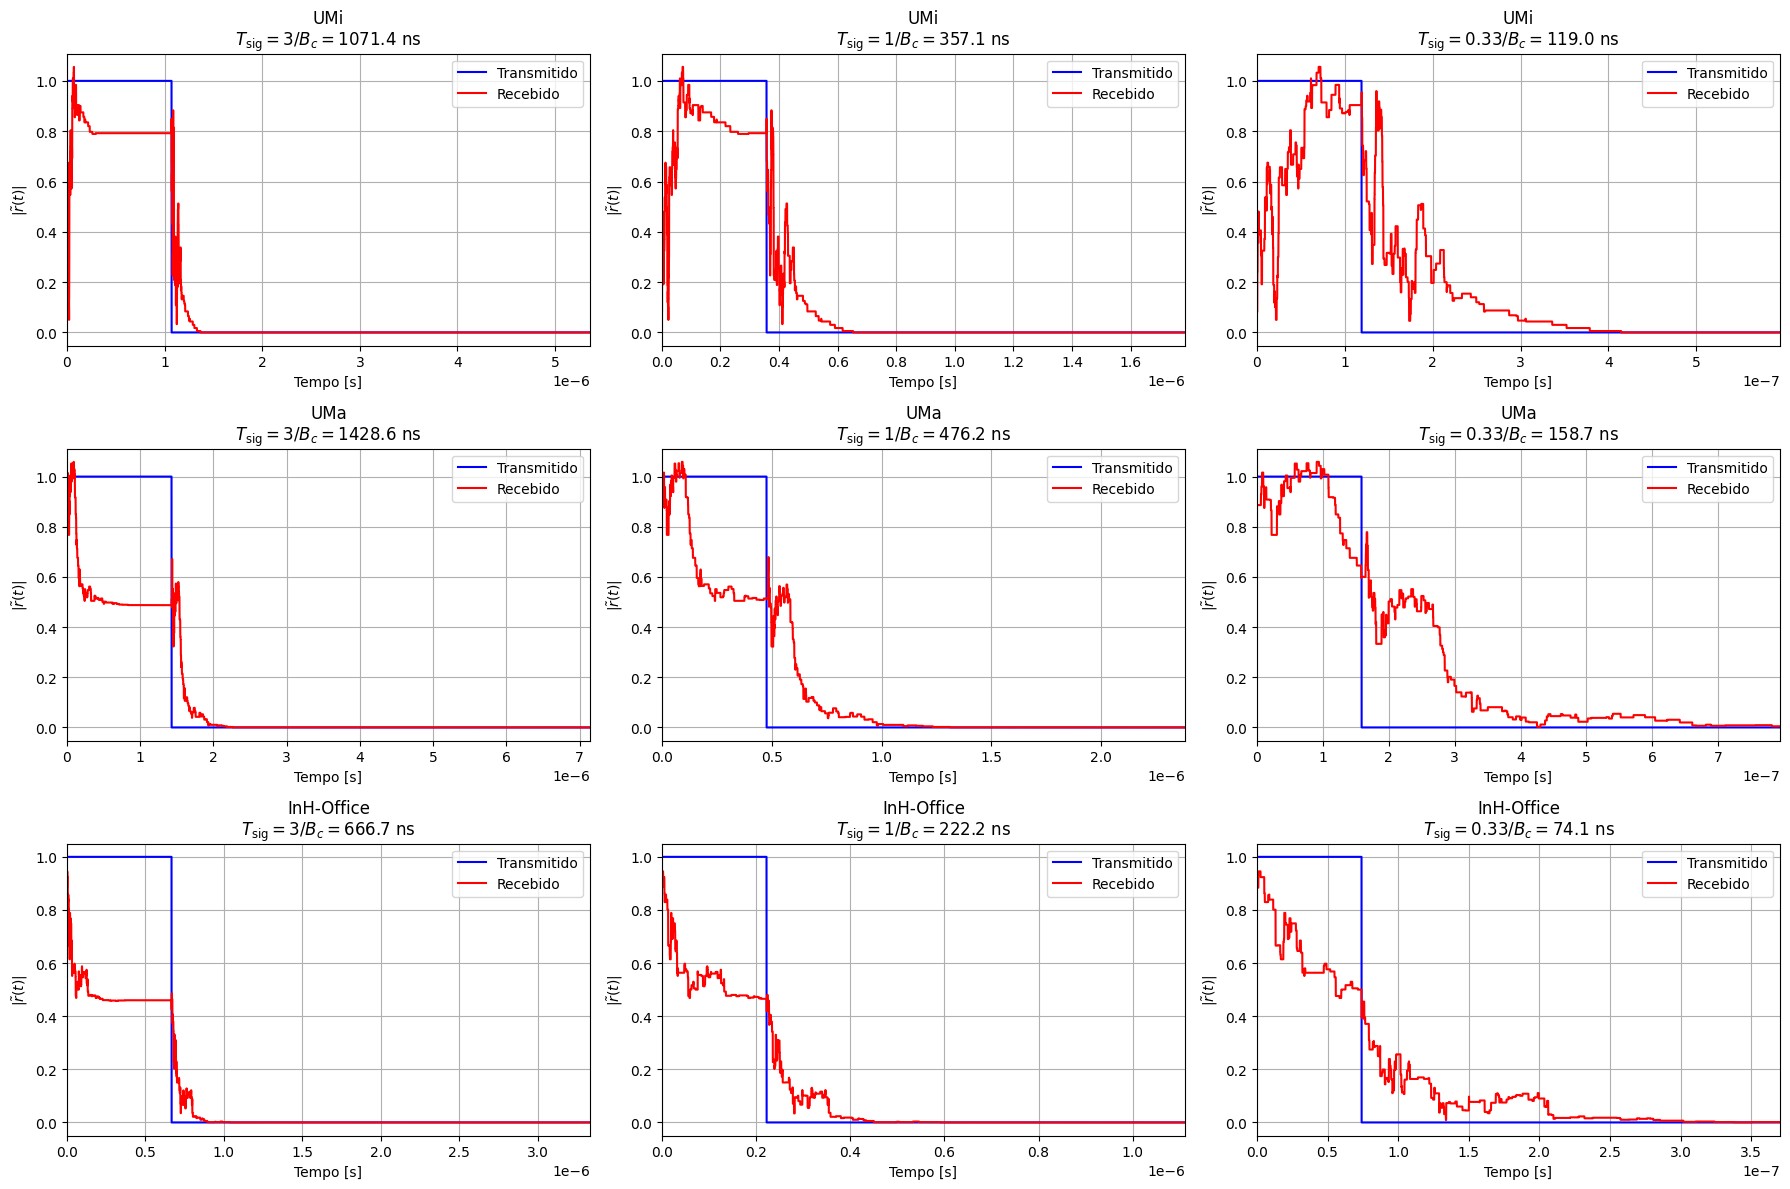

In [9]:
def create_rect(duration, max_t=None, num_samples=int(1e5)):
    if max_t is None:
        max_t = duration * 5
    t = np.linspace(0, max_t, num_samples)
    signal = np.where(t < duration, 1.0, 0.0)
    return BaseBandSignal(FREQUENCY_GHZ, signal, t)

SCENARIO_TO_COHERENCE_BANDWIDTH = {
    TGPPChannelModelEnum.UMi: 2.8e6,
    TGPPChannelModelEnum.UMa: 2.1e6,
    TGPPChannelModelEnum.IndoorOpenOffice: 4.5e6,
}

fig = plt.figure(figsize=(18, 12))

factors = [
    3,
    1,
    1/3,
]

for row, l in enumerate(ALL_LINKS):
    channel = l.chn

    scenario = TGPP_CHANNEL_MODEL_ENUM_TO_READABLE[
        channel.channel_model
    ]

    Bc = SCENARIO_TO_COHERENCE_BANDWIDTH[
        channel.channel_model
    ]

    for col, factor in enumerate(factors):

        duration = factor / Bc

        l.tx.signal = create_rect(duration)

        l.transmit()

        ax = fig.add_subplot(
            3, 3,
            row * 3 + col + 1,
        )

        plot_received_signal(
            l.rx.signal.t,
            l.tx.signal.x,
            l.rx.signal.x,
            ax=ax,
            title=(
                f"{scenario}\n"
                rf"$T_\text{{sig}} = {factor:.2g}/B_c"
                rf" = {duration*1e9:.1f}\ \mathrm{{ns}}$"
            )
        )

fig.tight_layout()

Nota-se que, quanto menor o período do pulso, maior a sua tendência a se "espalhar" após passar pelo canal. A utilização de $T_\text{sig} = 1/B_C$ como um limiar mostra-se adequado, pois a utilização de um período menor do que esse implica em interferência inter-simbólica maior, como visto em todos os gráficos à direita. No entanto, escolher um período maior do que esse implica em interferência inter-simbólica aparentemente desprezível.

# Conclusão

O trabalho implementa simulações adaptadas dos cenários UMi, UMa e InH-Office. Uma realização de cada cenário é simulada para realização de análises. São consideradas as dispersões de potência nos domínios de atraso, de elevação, azimutal e Doppler para análise, além das funções de autocorrelação no tempo e na frequência. Por fim, a banda de coerência determinada permite observar a filtragem que o canal realiza sobre sinais retangulares transmitidos. A implementação pode ser encontrada no link [github.com/artistrea/tgpp](https://github.com/artistrea/tgpp) .

Dentre as diferenças da implementação para o documento original do 3GPP, é importante notar que não foram consideradas correlações espaciais ou entre os parâmetros de larga escala.

Em relação ao documento que motiva este trabalho, algumas considerações adicionais foram feitas. A normalização dos ângulos de elevação são necessárias para manter sentido físico das direções de chegada, evitando problemas com a conversão em vetores de chegada. O espalhamento de atraso gerado e efetivo possui diferença significativa para as realizações com LoS, pois a aplicação do fator de Rice muda significativamente a distribuição de potência no domínio do atraso. Todos os outros valores se encontram de acordo com o esperado.


Sendo assim, os objetivos desse trabalho foram concluídos com sucesso, obtendo um simulador funcional e análises de diversos cenários como resultados.



# Bibliografia
[1] Higo Thaian P. Da Silva. Comunicações Móveis - Simulação do Canal de Comunicação Sem Fio. 2026.

[2] 3GPP. Study on channel model for frequencies from 0.5 to 100 GHz. Rel. técn. TR 38.901 V16.1.0. 2020.

[3] ITU-R. Characteristics of terrestrial IMT-Advanced systems for frequency sharing/interference analyses. Recommendation ITU-R M.2292-0. 2015.

<!-- TODO: falar do mapeamento ISD -> raio na apresentação -->